In [12]:
import os

BASE_DIR = "ABSOLUTE_PATH_TO_THE_ROOT"
DATA_DIR = os.path.join(BASE_DIR, "data")
CODE_DIR = os.path.join(BASE_DIR, "code")
FC_DIR = os.path.join(BASE_DIR, 'models_save/fc')
UC_DIR = os.path.join(BASE_DIR, 'models_save/uc')

import sys

sys.path.append(CODE_DIR)

In [29]:
import json

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, KernelPCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from matplotlib import pyplot as plt

from models.uncertainty.dist_match.tree import DistMatchQRF
from models.uncertainty.dist_match.utils import match_ks_raw

from sklearn_quantile import RandomForestQuantileRegressor

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
def matcher(x1, x2):
    return match_ks_raw(x1, x2) > 0.25

In [ ]:
tree_path = "ABSOLUTE_PATH_TO_PROJECT_ROOT/models_save/uc/qrf_ks_electricelectricity-normalized.pkl"
qrf = DistMatchQRF(
    alpha=0.1,
    n_quantile_bins=10,
    feature_dim=-1,
    matcher=matcher,
    match_mask=None,
    n_trees=10,
    bagging_ratio=0.9,
    verbose=False,
)
qrf.load_trees(tree_path)

In [35]:
leaf_node = qrf.trees[0].leaf_nodes[-1]
xs, ys, _ = leaf_node.values

In [40]:
def get_quantile(xs, ys, x, quantiles=[0.05, 0.95]):
    n_samples = len(xs)
    assert n_samples == len(ys)
    xs = xs.reshape(n_samples, -1)
    ys = ys.reshape(n_samples)
    x = x.reshape(1, -1)

    return (
        RandomForestQuantileRegressor(
            n_estimators=10,
            max_depth=2,
            criterion="squared_error",
            q=quantiles,
        )
        .fit(xs, ys)
        .predict(x)
        .squeeze()
    )

(-2.2461395007371903, 1.8897021752595902, 0.0, 33.6)

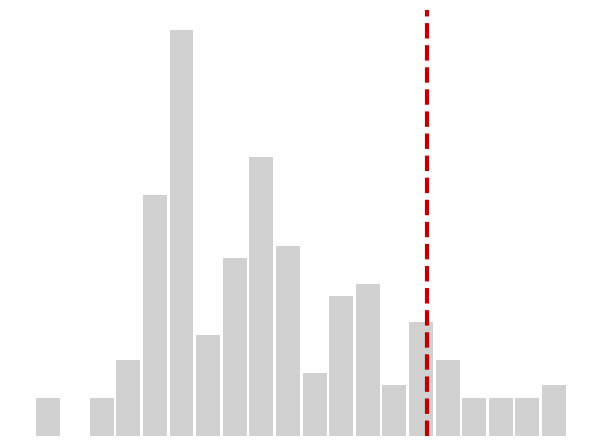

In [114]:
test_quantiles = get_quantile(xs, ys, xs[11])

plt.hist(ys, bins=20, color="#d1d1d1", rwidth=0.9)
plt.axvline(test_quantiles[1], ymin=0, ymax=32, color="#c00000", linestyle="dashed", linewidth=3)
plt.tight_layout()
plt.xticks([]),plt.yticks([])
plt.axis('off')